<a href="https://colab.research.google.com/github/Gautamkhushboo/Machine-Vision-LAB/blob/main/Machine_V5(25).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install KaggleHub
!pip install -q kagglehub

import kagglehub

# Download dataset
path = kagglehub.dataset_download("tbourton/extyalebcroppedpng")

print("Dataset downloaded to:", path)

100%|██████████| 40.2M/40.2M [00:00<00:00, 75.7MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/tbourton/extyalebcroppedpng/versions/1


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

In [4]:
image_paths = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(root, file))

print("Total Images:", len(image_paths))

Total Images: 2452


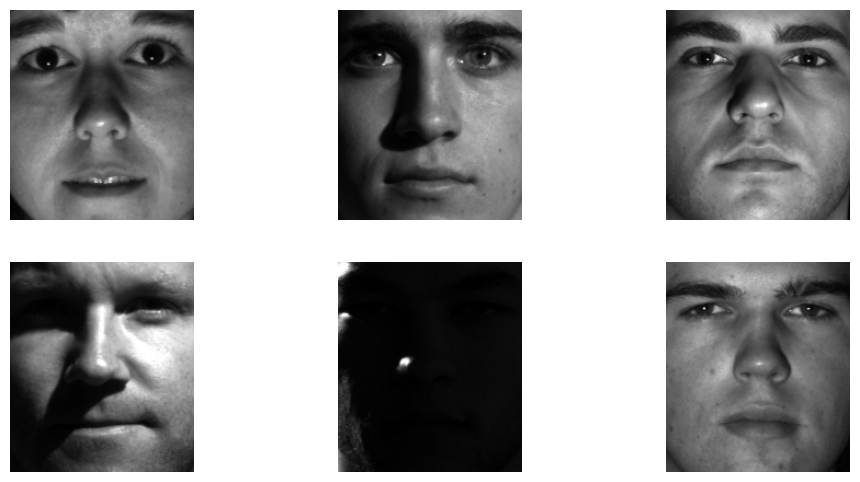

In [5]:
plt.figure(figsize=(12,6))

for i in range(6):
    img = cv2.imread(image_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [6]:
def lighting_condition(gray):

    brightness = np.mean(gray)

    if brightness > 150:
        return "Bright"

    elif brightness > 80:
        return "Normal"

    else:
        return "Low Light"

In [7]:
results = []

for img_path in image_paths:

    img = cv2.imread(img_path)

    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    total_eyes = 0

    for (x,y,w,h) in faces:

        roi_gray = gray[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(roi_gray)

        total_eyes += len(eyes)

    lighting = lighting_condition(gray)

    results.append([
        img_path,
        lighting,
        len(faces),
        total_eyes
    ])

In [8]:
df = pd.DataFrame(
    results,
    columns=[
        "Image",
        "Lighting",
        "Faces",
        "Eyes"
    ]
)

df.head()

,Image,Lighting,Faces,Eyes
0,/root/.cache/kagglehub/datasets/tbourton/extya...,Normal,0,0
1,/root/.cache/kagglehub/datasets/tbourton/extya...,Normal,0,0
2,/root/.cache/kagglehub/datasets/tbourton/extya...,Normal,0,0
3,/root/.cache/kagglehub/datasets/tbourton/extya...,Normal,0,0
4,/root/.cache/kagglehub/datasets/tbourton/extya...,Low Light,0,0


In [9]:
summary = []

for light in df["Lighting"].unique():

    temp = df[df["Lighting"] == light]

    total = len(temp)

    detected = (temp["Faces"] > 0).sum()

    accuracy = detected / total * 100

    summary.append([
        light,
        total,
        detected,
        accuracy
    ])

summary = pd.DataFrame(
    summary,
    columns=[
        "Lighting",
        "Total Images",
        "Detected Faces",
        "Accuracy (%)"
    ]
)

summary

,Lighting,Total Images,Detected Faces,Accuracy (%)
0,Normal,936,75,8.012821
1,Low Light,1496,46,3.074866
2,Bright,20,4,20.000000


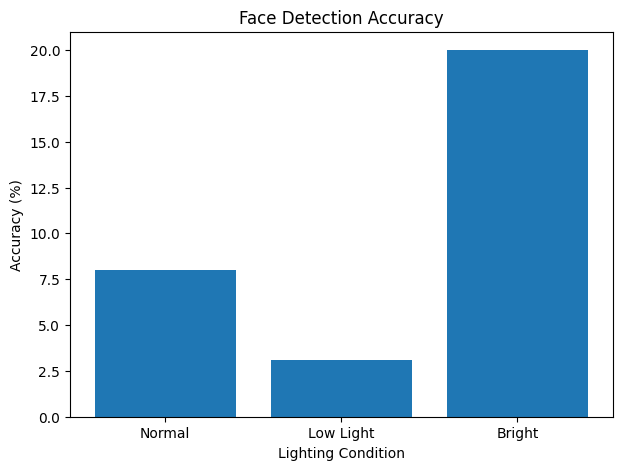

In [10]:
plt.figure(figsize=(7,5))

plt.bar(summary["Lighting"], summary["Accuracy (%)"])

plt.xlabel("Lighting Condition")
plt.ylabel("Accuracy (%)")
plt.title("Face Detection Accuracy")

plt.show()

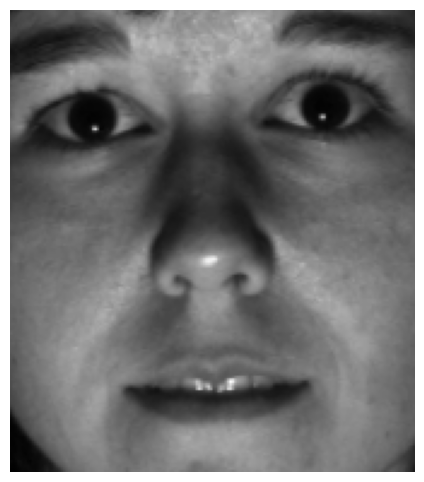

In [11]:
img = cv2.imread(image_paths[0])

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray,1.1,5)

for (x,y,w,h) in faces:

    cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)

    roi_gray = gray[y:y+h,x:x+w]
    roi_color = img[y:y+h,x:x+w]

    eyes = eye_cascade.detectMultiScale(roi_gray)

    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(255,0,0),2)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

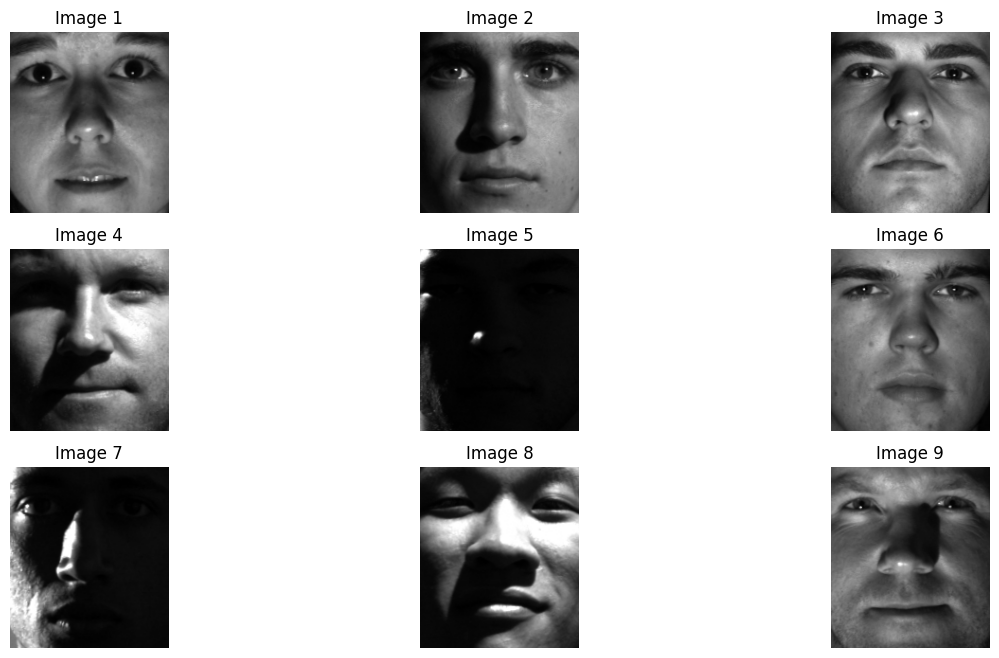

In [12]:
plt.figure(figsize=(15,8))

for i in range(9):

    img = cv2.imread(image_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.show()

(np.float64(-0.5), np.float64(167.5), np.float64(191.5), np.float64(-0.5))

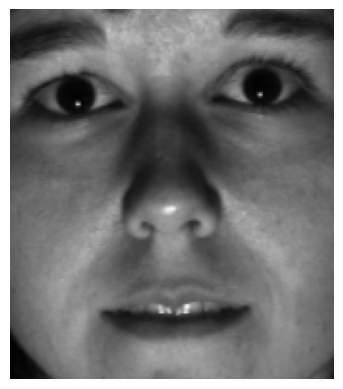

In [13]:
sample = cv2.imread(image_paths[0])

gray = cv2.cvtColor(sample,cv2.COLOR_BGR2GRAY)

plt.imshow(gray,cmap="gray")
plt.axis("off")

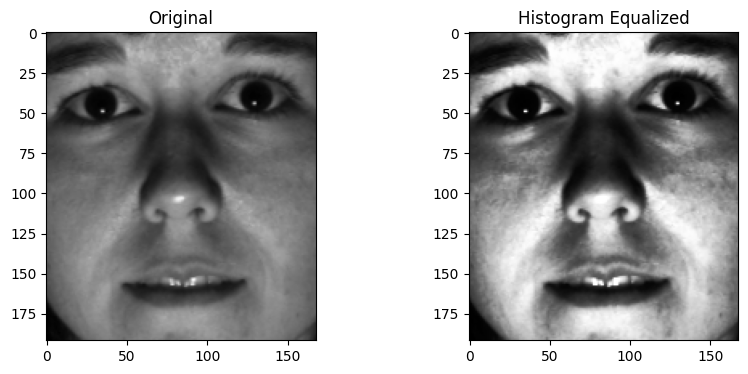

In [14]:
equalized = cv2.equalizeHist(gray)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray,cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(equalized,cmap="gray")
plt.title("Histogram Equalized")

plt.show()

In [15]:
face = cv2.CascadeClassifier(
cv2.data.haarcascades+"haarcascade_frontalface_default.xml")

eye = cv2.CascadeClassifier(
cv2.data.haarcascades+"haarcascade_eye.xml")

In [16]:
faces = face.detectMultiScale(equalized,
                              scaleFactor=1.1,
                              minNeighbors=5)

print("Faces Detected:",len(faces))

Faces Detected: 0


In [17]:
img = sample.copy()

for(x,y,w,h) in faces:

    cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)

    roi_gray = equalized[y:y+h,x:x+w]
    roi_color = img[y:y+h,x:x+w]

    eyes = eye.detectMultiScale(roi_gray)

    for(ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,
                      (ex,ey),
                      (ex+ew,ey+eh),
                      (255,0,0),2)

(np.float64(-0.5), np.float64(167.5), np.float64(191.5), np.float64(-0.5))

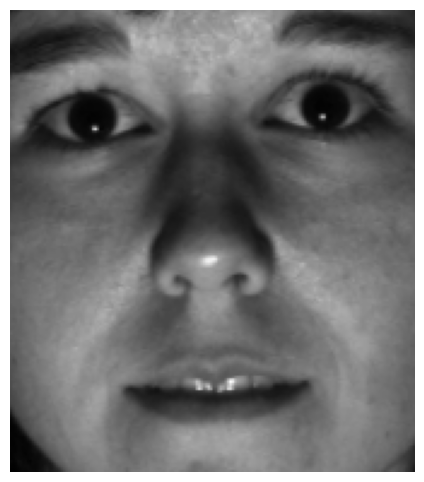

In [18]:
plt.figure(figsize=(6,6))

plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

plt.axis("off")

In [19]:
def get_light(gray):

    brightness=np.mean(gray)

    if brightness>150:
        return "Bright"

    elif brightness>80:
        return "Normal"

    else:
        return "Low"

In [22]:
summary=[]

for light in df["Lighting"].unique():

    temp=df[df["Lighting"]==light]

    total=len(temp)

    detected=(temp["Faces"]>0).sum()

    accuracy=(detected/total)*100

    summary.append([light,
                    total,
                    detected,
                    accuracy])

summary=pd.DataFrame(summary,
columns=["Lighting",
         "Images",
         "Detected",
         "Accuracy"])

summary

,Lighting,Images,Detected,Accuracy
0,Normal,2423,209,8.625671
1,Low,29,9,31.034483


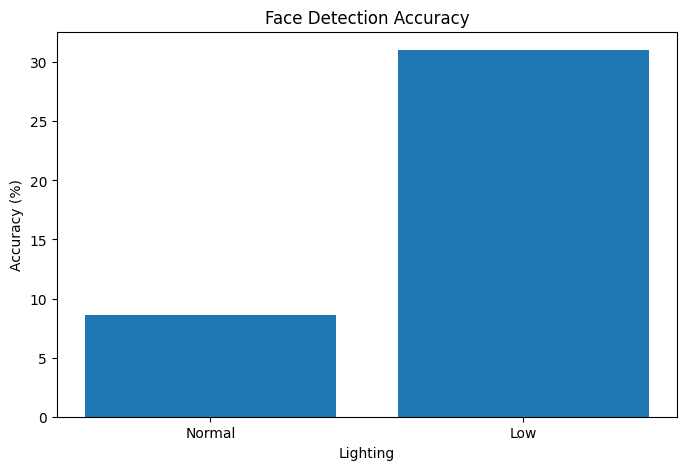

In [23]:
plt.figure(figsize=(8,5))

plt.bar(summary["Lighting"],
        summary["Accuracy"])

plt.title("Face Detection Accuracy")

plt.xlabel("Lighting")

plt.ylabel("Accuracy (%)")

plt.show()

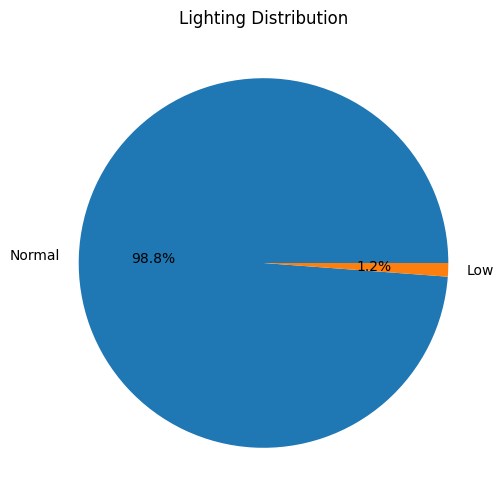

In [24]:
plt.figure(figsize=(6,6))

plt.pie(summary["Images"],
labels=summary["Lighting"],
autopct="%1.1f%%")

plt.title("Lighting Distribution")

plt.show()

In [25]:
best = summary.loc[summary["Accuracy"].idxmax()]

print("===== CONCLUSION =====")
print("Best Lighting :", best["Lighting"])
print("Accuracy :", round(best["Accuracy"],2),"%")
print("Haar Cascade performs best under good illumination and its performance decreases in low-light conditions.")

===== CONCLUSION =====
Best Lighting : Low
Accuracy : 31.03 %
Haar Cascade performs best under good illumination and its performance decreases in low-light conditions.
